# Sistemas de Recomendación - Tu Futuro según la Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## EDA

### Definición del problema
> - Este proyecto propone construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

## Recopilación de datos

In [4]:
df = pd.read_csv('../data/adult-census-income.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../data/adult-census-income.csv'

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#### Observaciones:
> - El data frame se compone de 32561 filas y 15 columnas de tipo int64(6) y  object(9).
> - No hay valores nulos.

In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
df.drop_duplicates(inplace=True)

#### Observaciones:
> -  Se encontraron 24 duplicados que fueron eliminados.

### Variables definidas

> - `age`: Edad de la persona.	`Numérico`
> - `workclass`: Categoría laboral (Privado, Gobierno, Autoempleado, etc.).	`Categórico`
> - `fnlwgt`: Peso final (estimación de personas con características parecidas a la del individuo).	`Numérico`
> - `education`: Máximo nivel educativo alcanzado (Bachillerato, Licenciatura, etc.).	`Categórico`
> - `education.num`: El mismo nivel educativo convertido a un número (ej: 9 = HS-grad).	`Numérico`
> - `marital.status`: Estado civil actual (Casado, Divorciado, Viudo, etc.).	`Categórico`
> - `occupation`: Tipo de trabajo o profesión que desempeña.	`Categórico`
> - `relationship`: Parentesco o rol dentro del núcleo familiar (Esposo, Hijo, etc.).	`Categórico`
> - `race`: Raza o etnia de la persona.	`Categórico`
> - `sex`: Género de la persona.	`Categórico`
> - `capital.gain`: Ganancias obtenidas por inversiones o ventas de activos.	`Numérico`
> - `capital.loss`: Pérdidas financieras por inversiones o ventas de activos.	`Numérico`
> - `hours.per.week`: Cantidad de horas que la persona trabaja a la semana.   `Numérico`
> - `native.country`: País de origen.     `Categórico`
> - `income`:	Variable Objetivo: Si la persona gana más o menos de $50,000 anuales.	`Categórico`

## Limpieza de datos.

In [ ]:
df.drop(['education', 'fnlwgt'], axis=1, inplace=True)
df['high_income'] = np.where(df['income'] == '>50K', 1, 0)
df.replace("?", 'Unknown', inplace=True)

#### Observaciones:
> - La eliminación de la variable `education` se debe a que `education.num` es su tabla numérica equivalente.
> - Se elimina `fnlwgt`, porque para este modelo no interesa saber qué proporción de la población representa un individuo.
> - La variable objetivo pasa a ser binaria, ahora se llama `high_income`.
> - Las variables con el valor (?), serán reemplazados como valores nulos.
> - Los valores nulos se completaran con la palabra `unknown`.

## Define el problema de recomendación. Plantea cómo vas a estructurar tu sistema de recomendación:

### ¿Qué se quiere recomendar?
Se quiere recomendar un cambio en la  situación de su vida actual para poder alcanzar unos ingresos superiores al 50K anuales.




### ¿Cuál será el "usuario" en este caso?
El usuario puede ser cualquier individuo que desee utilizar el sistema de recomendación, sin embargo está enfocado a las personas que ganan menos de 50K y deseen propuestas para mejorar su situación económica.




### ¿Qué variables definen el perfil de un usuario?
>El perfil de usuario está definido por un vector de características sociodemográficas y laborales:


**Perfil Demográfico (Identidad):** age, sex, race, native.country. (Definen el punto de partida y el contexto personal).


**Perfil Socioeconómico (Situación):** education.num, marital.status, relationship. (Definen su entorno y nivel de preparación).


**Perfil Laboral (Esfuerzo):** occupation, workclass, hours.per.week. (Definen su actividad económica actual).

### Transformación de las características y la variable objetivo

#### Preparación

In [ ]:
df['native.country'].value_counts()

native.country
United-States                 29153
Mexico                          639
Unknown                         582
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        62
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece       

In [ ]:
df['native.country'] = np.where(df['native.country'] == 'United-States', 'United-States', 'Foreign')

In [ ]:
df['native.country'].value_counts()

native.country
United-States    29153
Foreign           3384
Name: count, dtype: int64

> - Al haber tanto paises y ser el mas predominante en el conjunto de datos United-states he optado por dejar unicamente dos valores con los cuales trabajar.
> -  Ahora se puede transformar la variable usando mapping.

In [ ]:
df['race'].value_counts()

race
White                 27795
Black                  3122
Asian-Pac-Islander     1038
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64

In [ ]:
categorias_validas = ['White', 'Black']
df['race'] = np.where(np.isin(df['race'], categorias_validas),df['race'], 'Other')
df['race'].value_counts()

race
White    27795
Black     3122
Other     1620
Name: count, dtype: int64

### Split

In [ ]:
X = df.drop('high_income', axis=1)
y = df['high_income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Transformación.

In [ ]:
cat_cols = ['workclass', 'race', 'sex', 'native.country', 'marital.status', 'occupation', 'relationship']
num_cols = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

In [ ]:
# Crear el Pipeline con XGBoost
pipeline_xgb = Pipeline(steps=[
    ('prep', preprocessor),
    ('modelo', XGBClassifier())
])

# Entrenar (Aquí se hace el fit_transform automático)
pipeline_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [ ]:
nombres_columnas = pipeline_xgb.named_steps['prep'].get_feature_names_out()
nombres_columnas

array(['cat__workclass_Local-gov', 'cat__workclass_Never-worked',
       'cat__workclass_Private', 'cat__workclass_Self-emp-inc',
       'cat__workclass_Self-emp-not-inc', 'cat__workclass_State-gov',
       'cat__workclass_Unknown', 'cat__workclass_Without-pay',
       'cat__race_Other', 'cat__race_White', 'cat__sex_Male',
       'cat__native.country_United-States',
       'cat__marital.status_Married-AF-spouse',
       'cat__marital.status_Married-civ-spouse',
       'cat__marital.status_Married-spouse-absent',
       'cat__marital.status_Never-married',
       'cat__marital.status_Separated', 'cat__marital.status_Widowed',
       'cat__occupation_Armed-Forces', 'cat__occupation_Craft-repair',
       'cat__occupation_Exec-managerial',
       'cat__occupation_Farming-fishing',
       'cat__occupation_Handlers-cleaners',
       'cat__occupation_Machine-op-inspct',
       'cat__occupation_Other-service', 'cat__occupation_Priv-house-serv',
       'cat__occupation_Prof-specialty',
       '

In [ ]:
df.columns

Index(['age', 'workclass', 'education.num', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'capital.gain', 'capital.loss',
       'hours.per.week', 'native.country', 'income', 'high_income'],
      dtype='object')

In [ ]:
y_pred = pipeline_xgb.predict(X_test)
accuracy_score(y_test, y_pred)


0.8716963736939152

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4988
           1       0.76      0.66      0.71      1520

    accuracy                           0.87      6508
   macro avg       0.83      0.80      0.81      6508
weighted avg       0.87      0.87      0.87      6508



#### Observaciones:
> - El modelo arroja una metrixa Accuracy de l 87% significa que es solido en términos generales.
> - La clase 0 (Ganan <50K) cuenta con un F1-score de 0.92. El modelo es casi perfecto identificando a este grupo.
> - La clase 1 (Ganan >50K): Aquí el F1-score es 0.71. Es más bajo porque hay menos ejemplos de gente con ingresos altos, pero un 0.76 de precisión significa que cuando el modelo dice que alguien es "exitoso", acierta el 76% de las veces.

Text(70.72222222222221, 0.5, 'Realidad (Datos)')

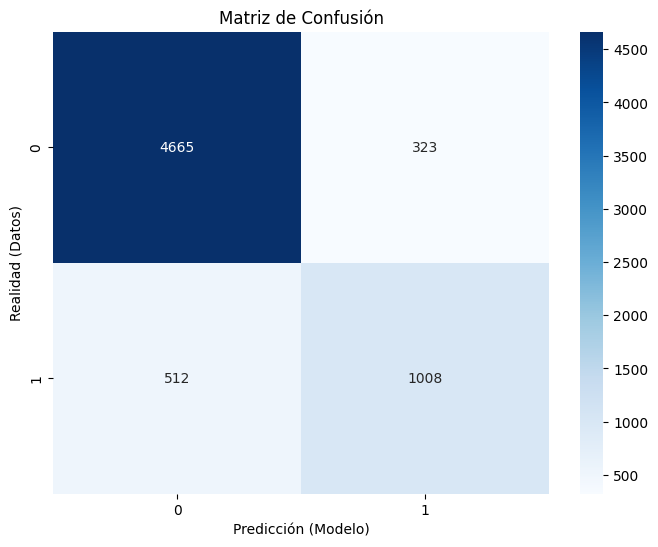

In [ ]:
# Crear la matriz
cm = confusion_matrix(y_test, y_pred)

# Graficar de forma elegante
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Datos)')

#### Observaciones:
> - El modelo identifica 4665 verdaderos negativos y 323 falsos positivos.
> - Predice 1008 verdaderos positivos y 512 falsos positivos.

### De Clasificador a Sistema de Recomendación

In [ ]:
pipeline_xgb.named_steps.keys()

dict_keys(['prep', 'modelo'])

Text(0.5, 0, 'Importancia')

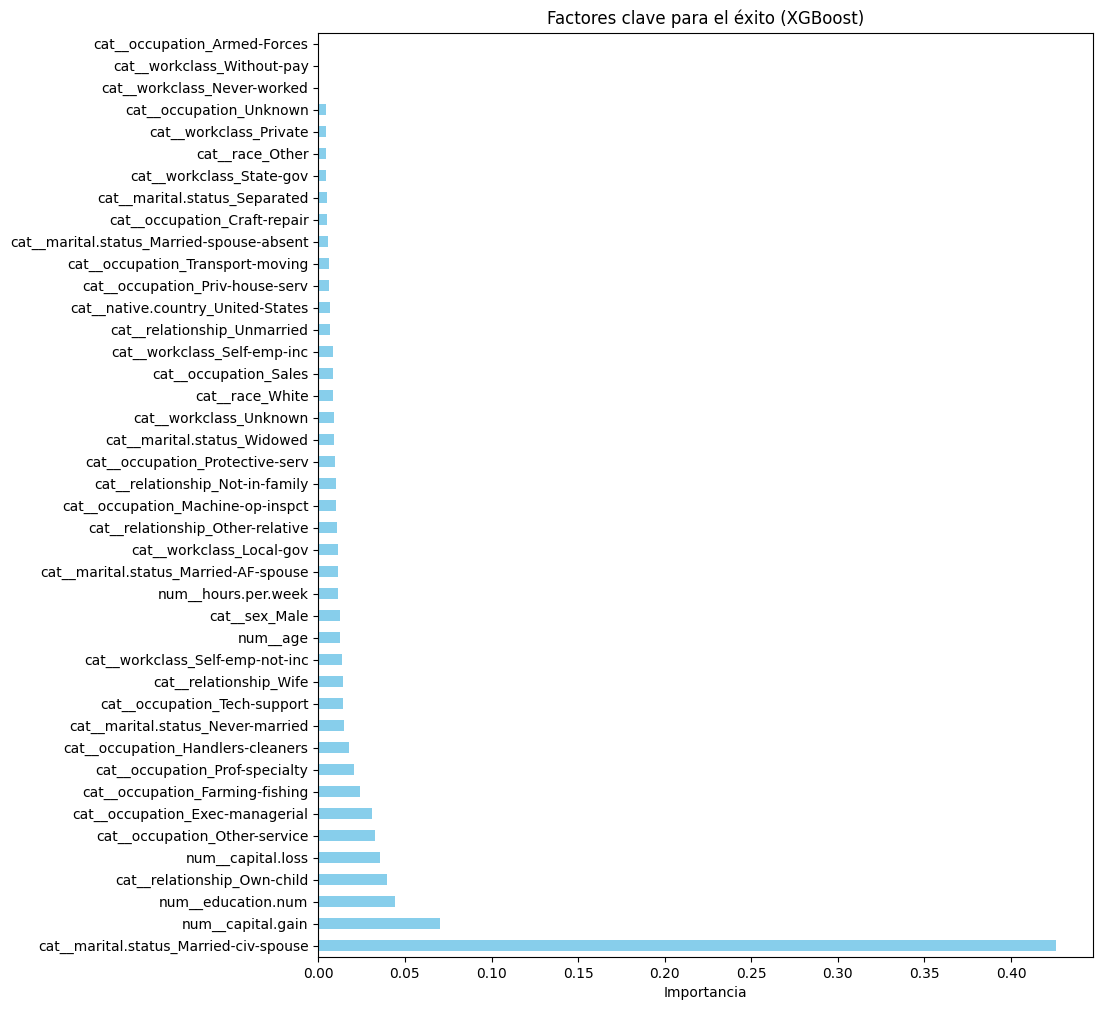

In [ ]:
#Se extraen los nombres de las columnas transformadas del preprocesador
feature_names_transformed = pipeline_xgb.named_steps['prep'].get_feature_names_out()

#Obtener las importancias
importances = pipeline_xgb.named_steps['modelo'].feature_importances_
plt.figure(figsize=(10, 12))

#Creamos la serie con los nombres correctos (ahora ambos miden 42)
pd.Series(importances, index=feature_names_transformed).sort_values(ascending=False).plot(kind='barh', color='skyblue')

plt.title("Factores clave para el éxito (XGBoost)")
plt.xlabel("Importancia")

#### Observaciones:
> - El modelo sugiere que la estabilidad del hogar es un factor determinante en la trayectoria económica, sin embargo no se le puede recomendar a alguien que se case para que mejore su situación financiera, ya que eso depende de muchos factores del individuo antes y después del matrimonio.
> - Me enfocare en la segunda y la tercera variable más importante para conseguir el éxito financiero education.num y capital.gain.

## Función de Recomendación.

In [ ]:
def recomendar_trayectoria(datos_usuario):
    #Crear DataFrame
    df_usuario = pd.DataFrame([datos_usuario])
    
    #Asegurar que las columnas coincidan EXACTAMENTE con X_train
    #Reindex ordena y añade las faltantes en un solo paso
    df_usuario = df_usuario.reindex(columns=X_train.columns)

    #PASO CLAVE: Rellenar nulos según el tipo de columna
    #Las numéricas con 0, las categóricas con 'Unknown' (o lo que usaste en el entrenamiento)
    for col in df_usuario.columns:
        if df_usuario[col].dtype == 'object' or col in cat_cols:
            df_usuario[col] = df_usuario[col].fillna('Unknown')
        else:
            df_usuario[col] = df_usuario[col].fillna(0)

    #Forzar que las columnas categóricas sean tratadas como string/object
    #Esto evita que el reindex las convierta en tipos extraños
    df_usuario[cat_cols] = df_usuario[cat_cols].astype(str)

    #Calcular la probabilidad
    try:
        prob_actual = pipeline_xgb.predict_proba(df_usuario)[0][1]

        df_mejorado = df_usuario.copy()
        df_mejorado['education.num'] = 13 
        prob_mejorada = pipeline_xgb.predict_proba(df_mejorado)[0][1]

        if prob_mejorada > prob_actual:
            print(f"\n💡 RECOMENDACIÓN:")
            print(f"Probabilidad actual: {prob_actual:.2%}")
            print(f"Si completas un grado universitario, subiría a: {prob_mejorada:.2%}")
            print(f"Incremento estimado: {prob_mejorada - prob_actual:+.2%}")
        else:
            print(f"Probabilidad actual: {prob_actual:.2%}")
            print("El cambio en educación no impacta significativamente la probabilidad.")

    except Exception as e:
        print(f"Error al predecir: {e}")
        # Tip de depuración: ver qué tipos de datos le están llegando al modelo
        print("\nTipos de datos actuales en el DataFrame:")
        print(df_usuario.dtypes)

#PERFIL DE USUARIO FICTICIO
usuario_ficticio = {
    "age": 25,
    "education.num": 9,
    "marital.status": "Never-married",
    "occupation": "Sales",
    "hours.per.week": 30,
    "sex": "Male",
    "native.country": "United-States",
    "capital.gain": 0,
    "capital.loss": 0,
    "workclass": "Private",
    "relationship": "Own-child"
}

# Ejecutar
recomendar_trayectoria(usuario_ficticio)


💡 RECOMENDACIÓN:
Probabilidad actual: 0.07%
Si completas un grado universitario, subiría a: 0.23%
Incremento estimado: +0.16%


c:\Users\villa\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\villa\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## Conclusiones:
> -  El modelo es capaz de predecir la probabilidad de que alguien gane más de 50K anuales y la función de recomendación es capaz de identificar qué variables son las que pueden ayudar al individuo a mejorar su situación financiera.